# Домашнє завдання: Інтерактивні візуалізації з Plotly

## Опис завдання
У цьому домашньому завданні ви будете створювати інтерактивні візуалізації з допомогою бібліотеки Plotly. Ви дізнаєтесь різницю між Plotly Express (швидкі графіки) та Graph Objects (повний контроль), та створите інтерактивний дашборд.

**Опис колонок:**
- `datetime` - дата та час
- `season` - сезон (1=весна, 2=літо, 3=осінь, 4=зима)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних


In [76]:
import pandas as pd
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
import numpy as np

# Завантаження даних
df = pd.read_csv(r"D:\Навчання\Data Analytics\КУРС DATA ANALIST\python\DATA\yulu_rental.csv")
df['datetime'] = pd.to_datetime(df['datetime'])

# Для plotly краще не встановлювати datetime як індекс
df['month'] = df['datetime'].dt.month
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()

# Додаємо назви сезонів
season_map = {1: 'Весна', 2: 'Літо', 3: 'Осінь', 4: 'Зима'}
df['season_name'] = df['season'].map(season_map)

## Завдання 1: Базовий інтерактивний лінійний графік (Plotly Express)

**Завдання:**
Створіть інтерактивний лінійний графік динаміки оренди за часом (рівень деталізації - як в даних) з можливістю zoom та hover.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яка перевага інтерактивного графіка над статичним?
2. Чому на графіку є "пробіли" - ділянки, де одна пряма лінія зʼєднує два "суцільних" блоки з даними? Як би ви це могли дослідити на статичному графіку?


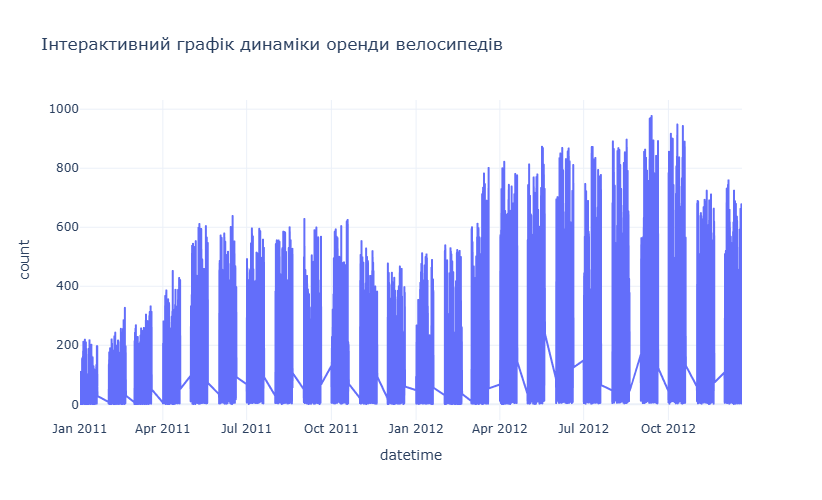

In [77]:
fig = px.line(df, x='datetime', y='count',
              title='Інтерактивний графік динаміки оренди велосипедів')
fig.update_layout(
    hovermode='x unified',
    template='plotly_white',
    height=500)
fig.show()

**1. Яка перевага інтерактивного графіка над статичним?**
- Яка перевага інтерактивного графіка над статичним?
- Можна наблизити будь-який фрагмент (zoom)
- Показує значення при наведенні (hover)
- Можна рухати графік, переміщатись по осі часу

**2. Чому на графіку є "пробіли" - ділянки, де одна пряма лінія зʼєднує два "суцільних" блоки з даними? Як би ви це могли дослідити на статичному графіку?**  
Це означає, що у певні періоди немає записів у даних: технічна відсутність даних або дані не фіксувались у цей період. 
На базовому лінійному графіку відсутність даних можна відслідкувати (ДЗ 1), але краще це покаже scatter plot, і на ньому розриви будуть очевидні.


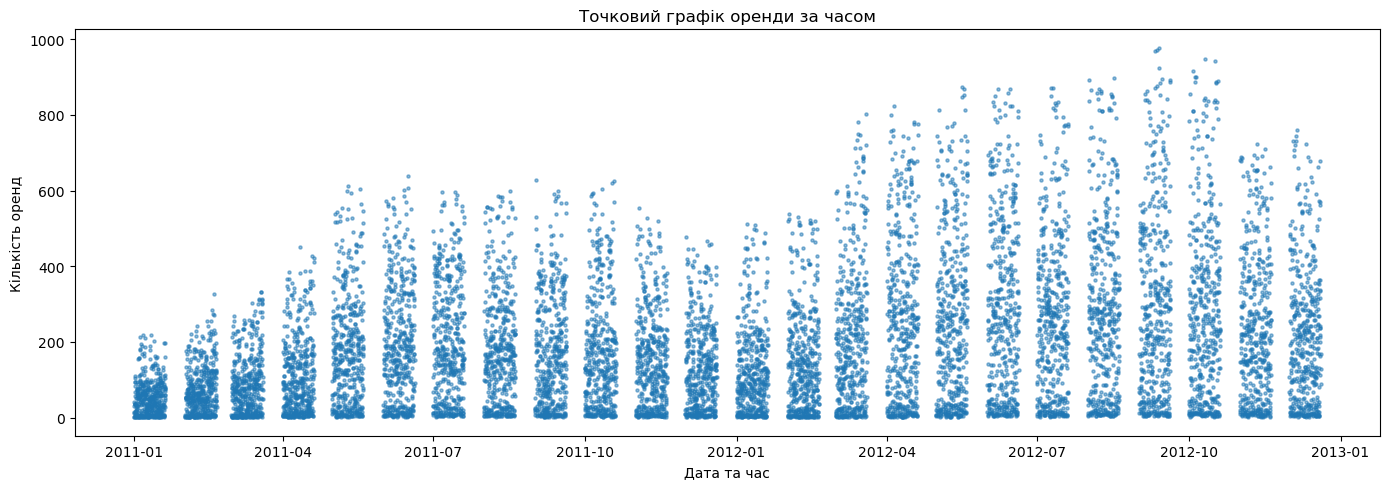

In [78]:
import matplotlib.pyplot as plt

plt.figure(figsize=(14, 5))
plt.scatter(df['datetime'], df['count'], s=5, alpha=0.5)
plt.title('Точковий графік оренди за часом')
plt.xlabel('Дата та час')
plt.ylabel('Кількість оренд')
plt.tight_layout()
plt.show()

## Завдання 2: Scatter plot з додатковими даними (Plotly Express)

**Завдання:**
Створіть scatter plot кількості орендованих велосипедів випадковими користувачами vs кількості орендованих велосипедів зареєстрованими користувачами. Розмір точок встановіть за сумарною кількістю велосипедів, які були взяті в оренду, а колір - за сезоном. В hover_data - додайте деталі, які допоможуть вам в подальшому аналізі.

Дослідіть графік. Зверніть увагу, що ви можете вмикати і вимикати окремі сезони, якщо будете клікати на колір сезону в легенді графіку.

**Дайте відповідь на питання.**
- Як ви проінтерпретуєте роздвоєність цього графіку (дві явні лінії)? Що це означає?
- Які висновки для компанії, які дає велосипеди в оренду, ви можете зробити з цього графіку? 3 основних висновки.

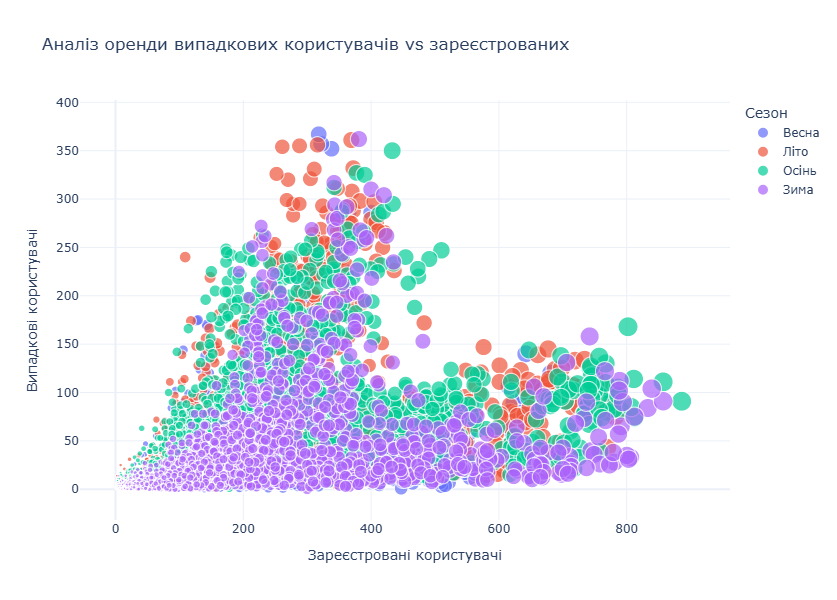

In [79]:
fig = px.scatter(df,
                 x='registered',
                 y='casual', 
                 size='count',
                 color='season_name',
                 hover_data=['datetime', 'weekday'],
                 title='Аналіз оренди випадкових користувачів vs зареєстрованих',
                   labels={
                     'casual': 'Випадкові користувачі',
                     'registered': 'Зареєстровані користувачі',
                     'count': 'Кількість оренд',
                     'season_name': 'Сезон'}
)
fig.update_layout(height=600,  
                  width=850,
                  template='plotly_white')
fig.show()

**1. Як ви проінтерпретуєте роздвоєність цього графіку (дві явні лінії)? Що це означає?**

Це означає, що ми маємо 2 різні моделі поведінки зареєстрованих та випадкових користувачів. Можливо оренда цими двома групами різниться за днями тижня (робочі vs вихідні дні), погодою та годинами доби.

**2. Які висновки для компанії, які дає велосипеди в оренду, ви можете зробити з цього графіку? 3 основних висновки.**

1. Є два основні сегменти користувачів: зареєстровані (ймовірно, які їздять регулярно на роботу чи навчання) та випадкові (перевжно туристи).  
2. Поведінка користувачів змінюється залежно від сезону. Влітку збільшується кількість випадкових оренд — туристи, відпочинок. Восени/взимку — більше зареєстрованих (регулярне використання, можливо для поїздок на роботу).  
3. Загальна кількість оренд (розмір точок) зростає, коли зростають і casual, і registered. Це означає, що для максимального завантаження сервісу бажано залучати обидва сегменти одночасно.


## Завдання 3: Порівняння Plotly Express vs Graph Objects

**Завдання:**
Створіть лінійний графік помісячної динаміки оренди велосипедів двома способами - з Plotly Express та з Graph Objects.

**Дайте відповіді на питання.**
1. Як ви розумієте основну різницю між цими двома підходами?
2. Коли краще використовувати Plotly Express?
3. Коли потрібен Graph Objects?


In [81]:
monthly_sum = df.resample('ME', on='datetime')['count'].sum().reset_index()

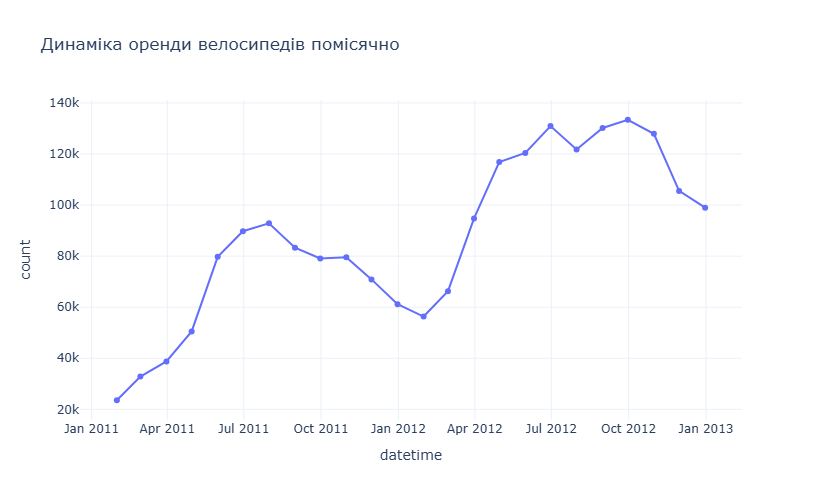

In [82]:
# Plotly Express
fig = px.line(monthly_sum,
              x='datetime',
              y='count',
              title='Динаміка оренди велосипедів помісячно',
              markers=True)
fig.update_layout(template='plotly_white',  height=500)
fig.show()

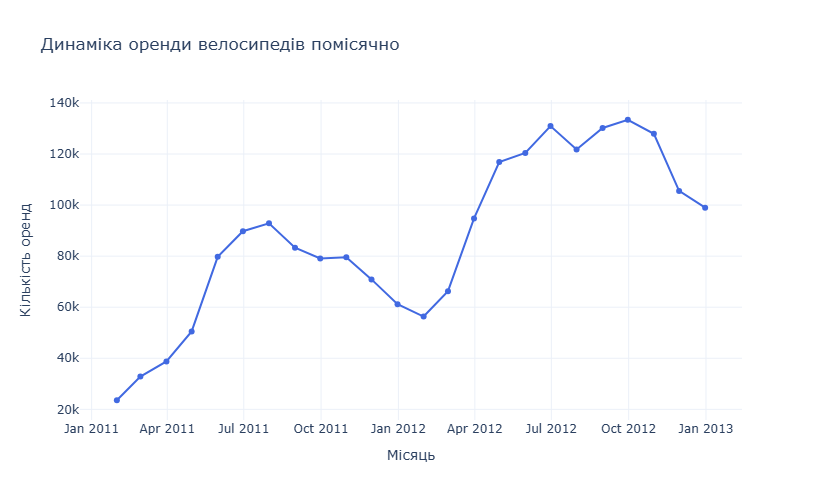

In [83]:
# Graph Objects

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=monthly_sum['datetime'],     # ось X — дата
    y=monthly_sum['count'],        # ось Y — кількість оренд
    mode='lines+markers',          # тип — лінія з точками
    name='Оренди',
    line=dict(color='royalblue', width=2)
))

fig.update_layout(
    title='Динаміка оренди велосипедів помісячно',
    xaxis_title='Місяць',
    yaxis_title='Кількість оренд',
    template='plotly_white',
    height=500,
    width=800
)

fig.show()

**1. Як ви розумієте основну різницю між цими двома підходами?**  
Plotly Express — це швидкий спосіб малювати красиві графіки одним рядком коду, а Graph Objects — це більш детальний і гнучкий інструмент для тонкого налаштування кожного елемента графіка.

**2. Коли краще використовувати Plotly Express?**  
Plotly Express зручно використовувати коли потрібно швидко створити простий графік з готовими підписами і мінімумом коду. Цуй підхід ідеальний для швидкого аналізу.

**3. Коли потрібен Graph Objects?**   
Graph Objects потрібен для створення багатьох графіків в одному полотні, складного дашборду, а такоож коли потрібні тонкі налаштування візуалізації, багато кастомних підписів, легенд і стилів.

## Завдання 4: Дашборд з make_subplots (Graph Objects)

**Завдання:**
Створіть дашборд з 4 різними графіками в одній фігурі:
- Bar chart - середні значення загальної кількості оренд велосипедів за сезонами
- Pie chart - відсоткове співвідношення погодних умов в даних
- Line chart - середнє значення загальної кількості оренд велосипедів за годинами протягом доби
- Scatter plot - кореляція температури vs вологість

Додайте заголовок на дашборд.

**Дайте відповідь на питання**
- На ваш погляд, яка перевага об'єднання графіків в один дашборд?

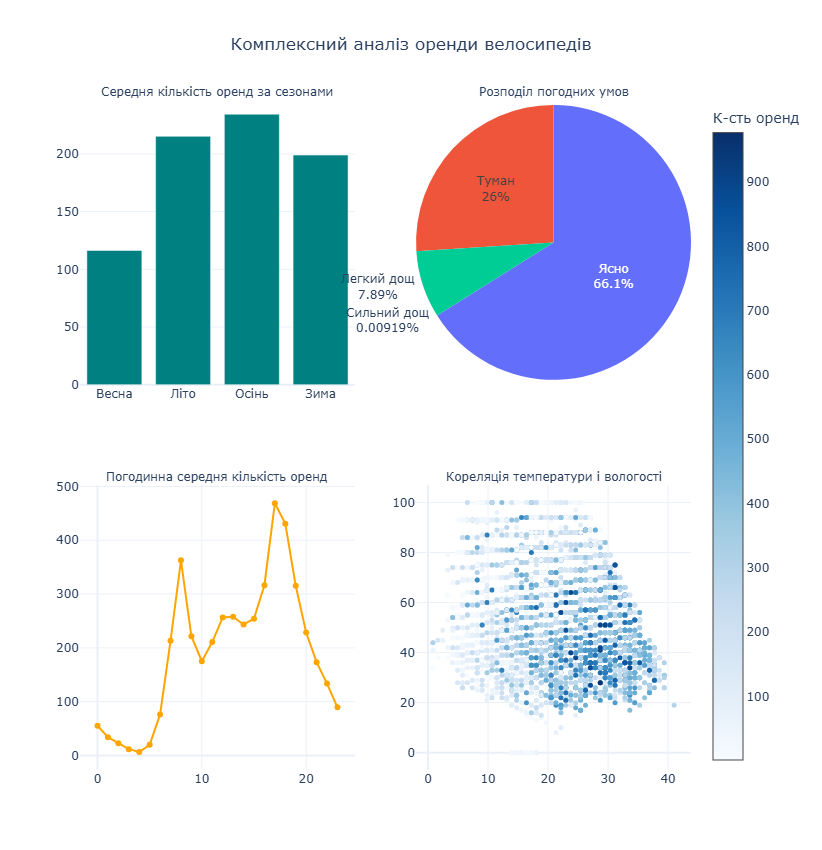

In [84]:
df['weather_label'] = df['weather'].map({1: 'Ясно', 2: 'Туман', 3: 'Легкий дощ', 4: 'Сильний дощ'})

# Створюємо дашборд
fig = make_subplots(
    rows=2, cols=2,
    subplot_titles=(
        'Середня кількість оренд за сезонами',
        'Розподіл погодних умов',
        'Погодинна середня кількість оренд',
        'Кореляція температури і вологості'
    ),
    specs=[[{"type": "bar"}, {"type": "pie"}],
           [{"type": "scatter"}, {"type": "scatter"}]],
    vertical_spacing=0.15,
    horizontal_spacing=0.1
)

# Графік 1: Bar chart
season_avg = df.groupby('season_name')['count'].mean().reindex(['Весна', 'Літо', 'Осінь', 'Зима'])

fig.add_trace(
    go.Bar(
        x=season_avg.index,
        y=season_avg.values,
        marker_color='teal',
        name='Сезони'
    ),
    row=1, col=1
)

# Графік 2: Pie chart
weather_counts = df['weather_label'].value_counts()

fig.add_trace(
    go.Pie(
        labels=weather_counts.index,
        values=weather_counts.values,
        textinfo='label+percent',
        showlegend=False
    ),
    row=1, col=2
)

# Графік 3: Line chart
hourly_avg = df.groupby('hour')['count'].mean()

fig.add_trace(
    go.Scatter(
        x=hourly_avg.index,
        y=hourly_avg.values,
        mode='lines+markers',
        line=dict(color='orange'),
        name='Погодинна оренда'
    ),
    row=2, col=1
)

# Графік 4: Scatter plot
fig.add_trace(
    go.Scatter(
        x=df['temp'],
        y=df['humidity'],
        mode='markers',
        marker=dict(
            size=5,
            color=df['count'],
            colorscale='Blues',
            showscale=True,
            colorbar=dict(title='К-сть оренд')
        ),
        name='Темп vs Вологість'
    ),
    row=2, col=2
)

fig.update_layout(
    height=850,
    width=1000,
    title_text="Комплексний аналіз оренди велосипедів",
    title_x=0.5,
    showlegend=False, 
    template='plotly_white'
)

fig.update_annotations(font_size=12)  # зменшуємо розмір підзаголовків

fig.show()


Дашборд дає можливість одночасно аналізувати різні типи графіків і, відповідно, різні типи даних, співвідношення, залежності тощо Це дозволяє швидше побачити взаємозв’язки, порівнювати і приймати рішення на основі комплексного огляду, а не по одному графіку.

## Завдання 5: 3D візуалізація

**Завдання:**
Створіть 3D scatter plot для аналізу взаємозв'язку температури, швидкості вітру та загальної кількості орендованих велосипедів. Колір встановіть за сезоном, а розмір - за загальною кількість оренд також.

Дайте відповіді на питання.
**Питання для інтерпретації:**
1. Яку додаткову інформацію, на ваш погляд, дає 3D візуалізація?
2. Чи видно кластери в 3D просторі?
3. Чи ви можете зробити висновки з цієї візуалізації, чи вам було простіше побудувати кілька 2D?



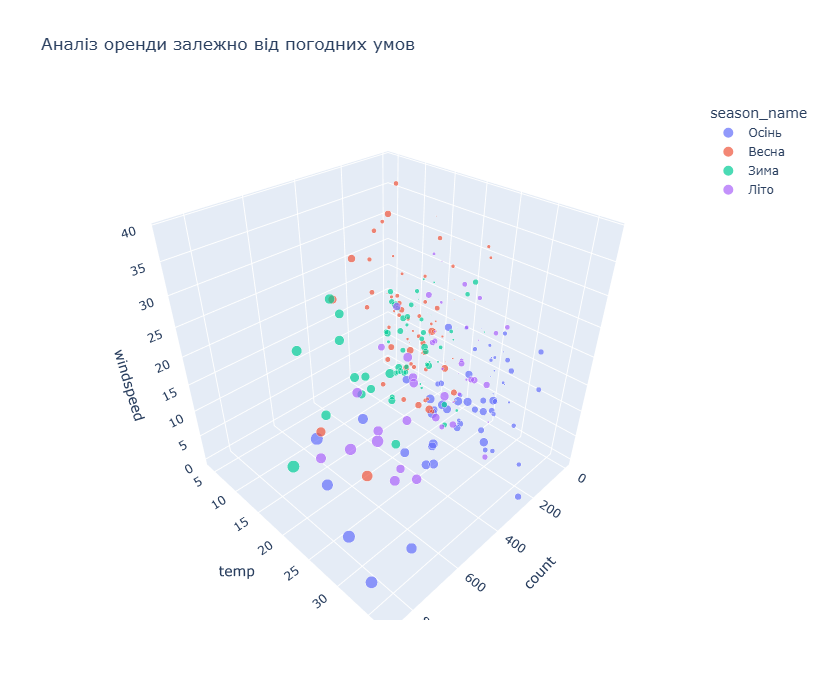

In [85]:
fig = px.scatter_3d(df.sample(250, random_state=42).reset_index(),
                    x='count', y='temp', z='windspeed',
                    color='season_name', size='count',
                    title='Аналіз оренди залежно від погодних умов')
fig.update_layout(height=700)
fig.show()

**1. Яку додаткову інформацію, на ваш погляд, дає 3D візуалізація?**  
3D-візуалізація дає змогу одночасно аналізувати взаємозв'язок трьох змінних — це зручно для виявлення потенційних залежностей або патернів, які складніше помітити в 2D.  

**2. Чи видно кластери в 3D просторі?**  
У представленій візуалізації чітко виражених кластерів не видно. Розподіл точок здається досить рівномірним, без явних груп.  

**3. Чи ви можете зробити висновки з цієї візуалізації, чи вам було простіше побудувати кілька 2D?**  
Мені важко зробити якісь висновки з цієї візуалізації, як на мене вона гарна, але не читабельна і не інформативна. Хоч вона і просто будується, але доцільніше було зробити кілька 2D графіків.


## Завдання 6: Експорт та збереження інтерактивних графіків

**Завдання:**
Збережіть побудований раніше дашборд в формат HTML. Також змініть вручну щось на дашборді (зум, виділення частини графіку) і збережіть його як статичне зображення через іконку фотоапарату у формат PNG. Завантажте файли з дашбордом у HTML та PNG (або посилання на них на github) разом з посиланням на цей ноутбук при здачі ДЗ.


In [86]:
fig.write_html("dashboard.html")